# 03 — Predictive Modeling

Can we predict which occupations will shift toward automation?

**Spoiler: barely.** After proper quality filtering, velocity prediction R² is near zero.
Direction classification achieves a modest AUC of ~0.71. The honest conclusion is that
individual occupation trajectories are hard to predict from current features — but we
can identify which *features* matter and understand the dominant dynamics.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_feature_matrix
from src.model import (
    train_velocity_models, train_tipping_models,
    rank_tipping_candidates, FEATURE_COLS,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261'}

In [2]:
features = build_feature_matrix()
print(f"Modeling with {len(features)} quality-filtered occupations")
print(f"\nTarget distributions:")
print(f"  Automation velocity: mean={features['automation_velocity'].mean():.4f}, "
      f"std={features['automation_velocity'].std():.4f}")
shifting = (features['automation_delta'] > 0).mean()
print(f"  Shifting toward automation: {shifting:.0%} of occupations")

Modeling with 319 quality-filtered occupations

Target distributions:
  Automation velocity: mean=0.0070, std=0.0340
  Shifting toward automation: 63% of occupations


## Part A: Predicting automation velocity (regression)

Target: rate of change in automation share across 4 releases.

In [3]:
vel_results = train_velocity_models(features)

print('Automation Velocity — Regression Results')
print('=' * 55)
for r in vel_results:
    print(f"\n{r.name}:")
    print(f"  R2 (train):  {r.metrics['r2_train']:.3f}")
    print(f"  R2 (5-fold): {r.metrics['r2_cv_mean']:.3f} +/- {r.metrics['r2_cv_std']:.3f}")
    print(f"  MAE:         {r.metrics['mae']:.4f}")

best_vel = max(vel_results, key=lambda r: r.metrics['r2_cv_mean'])
print(f"\nThe best CV R2 is {best_vel.metrics['r2_cv_mean']:.3f} — essentially no")
print(f"predictive power. The models overfit to training data (R2_train >> R2_cv).")
print(f"This is an honest finding: occupation-level automation velocity is not")
print(f"predictable from these features with this sample size.")

Automation Velocity — Regression Results

XGBoost:
  R2 (train):  0.959
  R2 (5-fold): -0.059 +/- 0.361
  MAE:         0.0052

GradientBoosting:
  R2 (train):  0.895
  R2 (5-fold): -0.018 +/- 0.269
  MAE:         0.0088

The best CV R2 is -0.018 — essentially no
predictive power. The models overfit to training data (R2_train >> R2_cv).
This is an honest finding: occupation-level automation velocity is not
predictable from these features with this sample size.


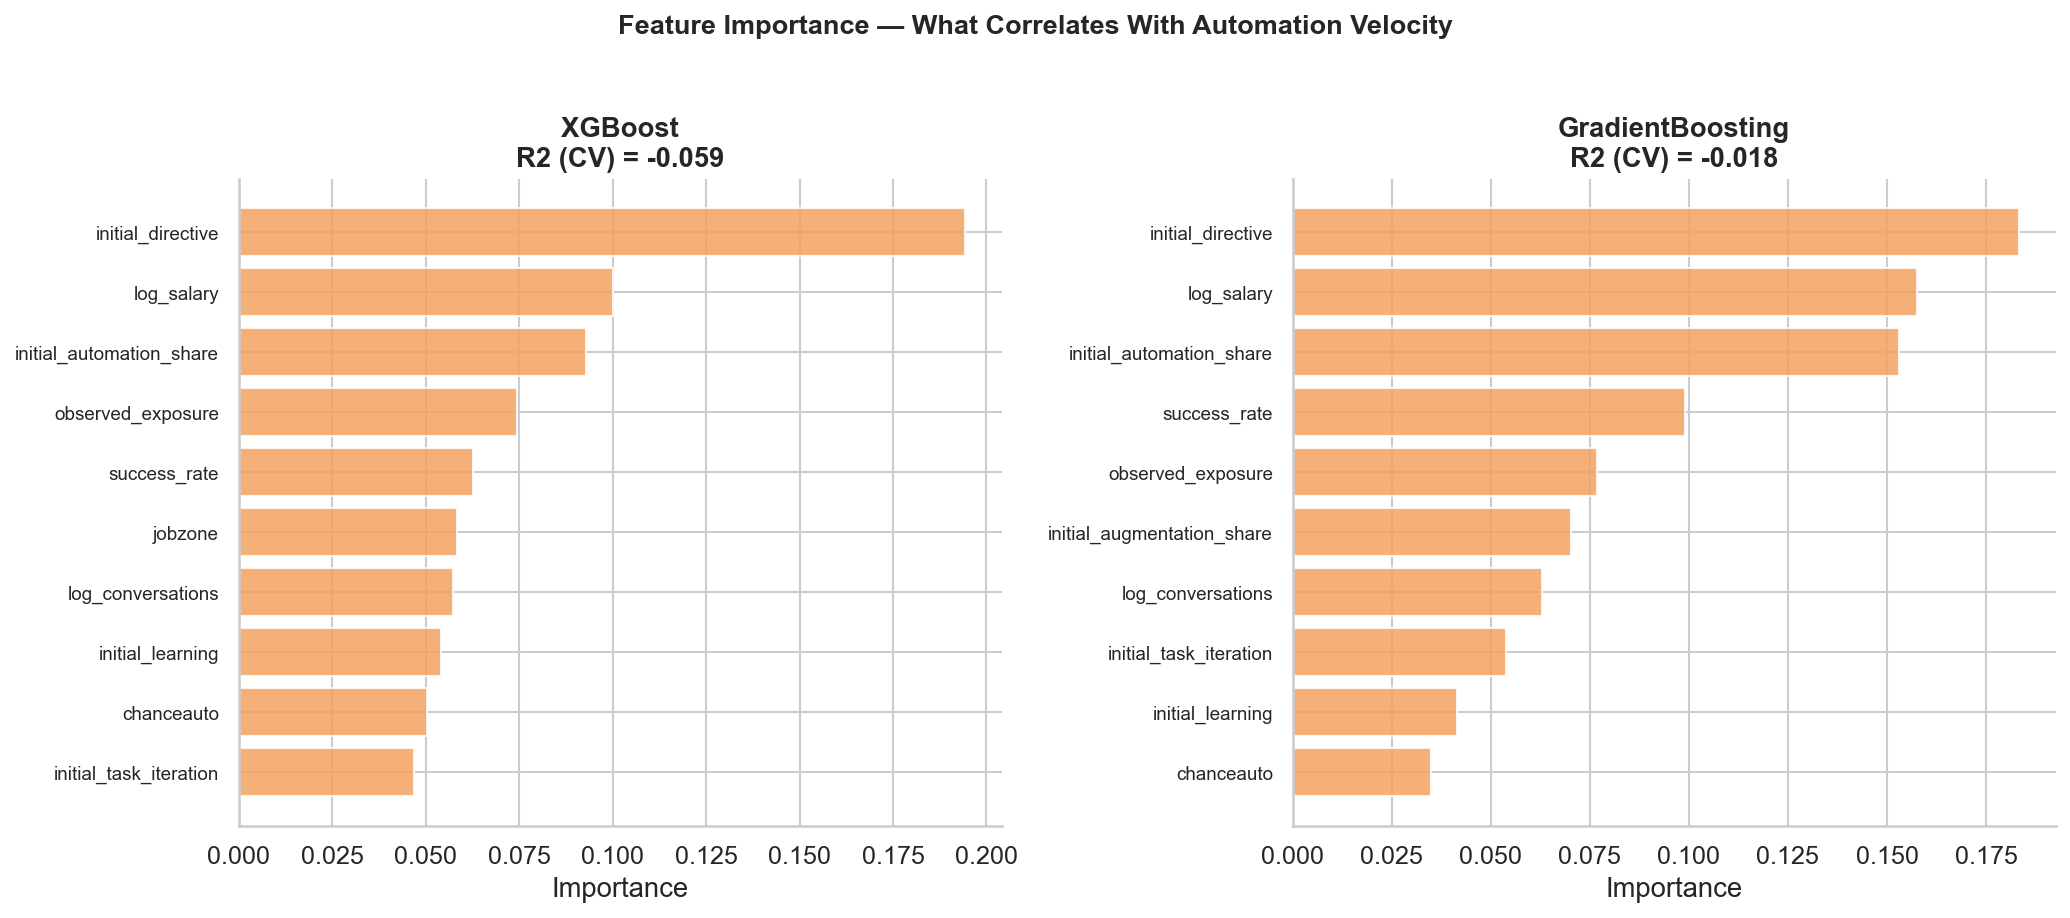

initial_directive is the top feature — this is mean reversion.
Occupations with high initial directive share decelerate.


In [4]:
fig, axes = plt.subplots(1, len(vel_results), figsize=(7 * len(vel_results), 6))
if len(vel_results) == 1:
    axes = [axes]

for ax, r in zip(axes, vel_results):
    imp = r.feature_importance.head(10)
    ax.barh(range(len(imp)), imp['importance'], color=C['accent'], alpha=0.85)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"{r.name}\nR2 (CV) = {r.metrics['r2_cv_mean']:.3f}", fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance — What Correlates With Automation Velocity',
             fontsize=13, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/09_velocity_feature_importance.png', bbox_inches='tight')
plt.show()

print("initial_directive is the top feature — this is mean reversion.")
print("Occupations with high initial directive share decelerate.")

## Part B: Predicting automation direction (classification)

Binary target: is the occupation's automation share increasing (delta > 0)?

In [5]:
tip_results = train_tipping_models(features)

print('Automation Direction — Classification Results')
print('=' * 55)
for r in tip_results:
    print(f"\n{r.name}:")
    print(f"  Accuracy:     {r.metrics['accuracy']:.3f}")
    print(f"  AUC (train):  {r.metrics['auc_train']:.3f}")
    print(f"  AUC (5-fold): {r.metrics['auc_cv_mean']:.3f} +/- {r.metrics['auc_cv_std']:.3f}")

best_clf = max(tip_results, key=lambda r: r.metrics['auc_cv_mean'])
print(f"\nBest: {best_clf.name} (AUC = {best_clf.metrics['auc_cv_mean']:.3f})")
print(f"Modest but real signal — better than random, worse than useful.")

Automation Direction — Classification Results

LogisticRegression:
  Accuracy:     0.740
  AUC (train):  0.765
  AUC (5-fold): 0.696 +/- 0.059

RandomForest:
  Accuracy:     0.915
  AUC (train):  0.976
  AUC (5-fold): 0.710 +/- 0.038

XGBoost_Classifier:
  Accuracy:     0.994
  AUC (train):  1.000
  AUC (5-fold): 0.677 +/- 0.044

Best: RandomForest (AUC = 0.710)
Modest but real signal — better than random, worse than useful.


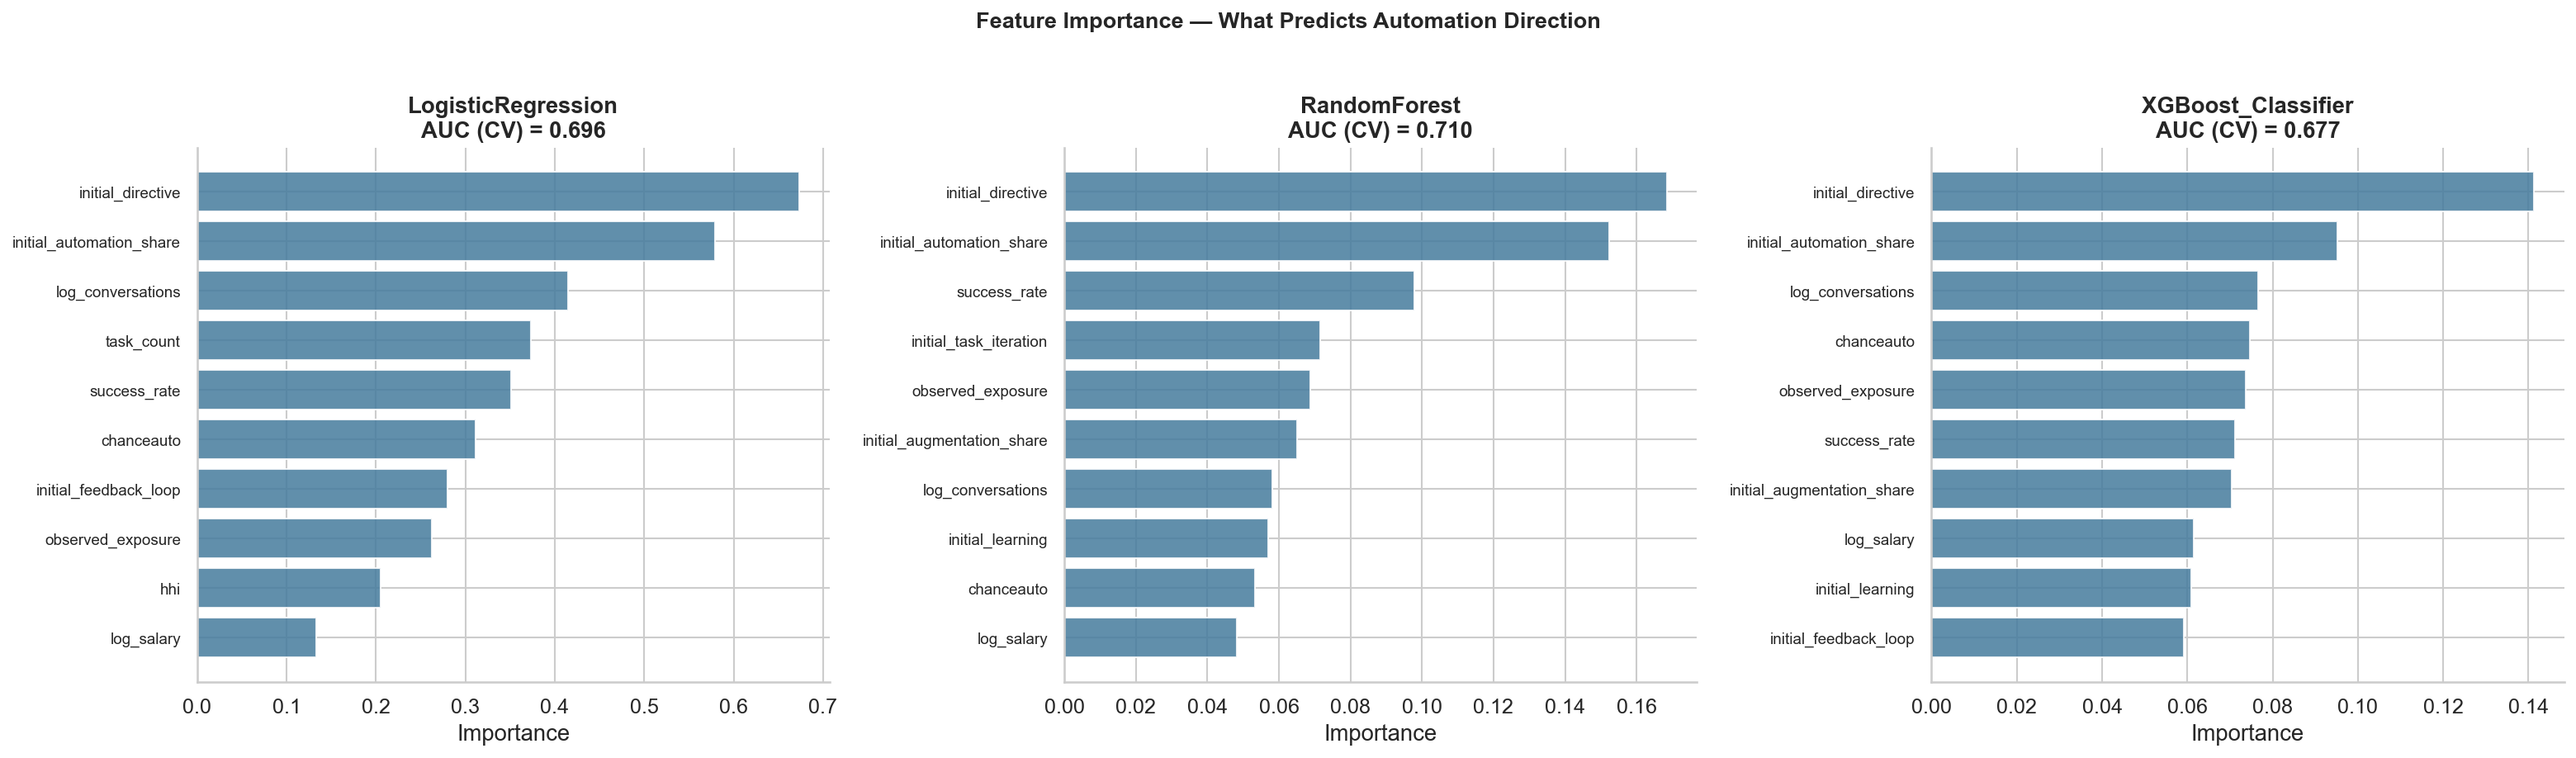

In [6]:
fig, axes = plt.subplots(1, len(tip_results), figsize=(7 * len(tip_results), 6))
if len(tip_results) == 1:
    axes = [axes]

for ax, r in zip(axes, tip_results):
    imp = r.feature_importance.head(10)
    ax.barh(range(len(imp)), imp['importance'], color=C['aug'], alpha=0.85)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"{r.name}\nAUC (CV) = {r.metrics['auc_cv_mean']:.3f}", fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance — What Predicts Automation Direction',
             fontsize=13, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/10_classification_feature_importance.png', bbox_inches='tight')
plt.show()

## Why the velocity model fails (and why that's interesting)

The gap between train R² and CV R² reveals overfitting. With only ~320 occupations
and 4 time points, there isn't enough signal to learn occupation-specific trajectories.

This is itself a finding: **the augmentation-to-automation transition is not a smooth,
predictable process driven by observable occupation characteristics.** It may depend
more on idiosyncratic factors — individual user behavior, specific tool availability,
or organizational adoption decisions — than on occupation-level features.

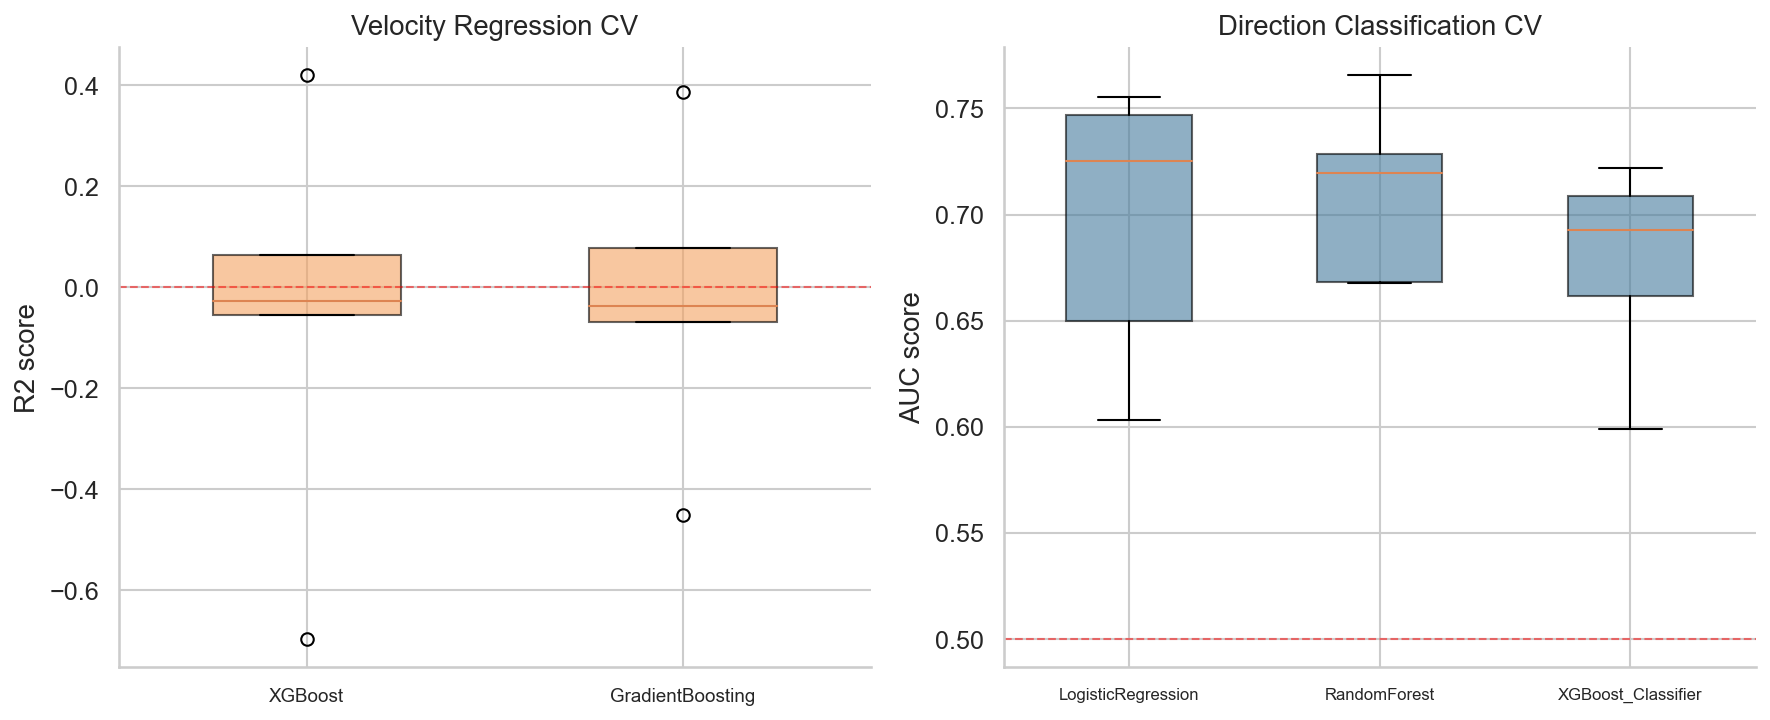

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

positions = range(len(vel_results))
bp1 = axes[0].boxplot([r.cv_scores for r in vel_results], positions=list(positions),
                       widths=0.5, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor(C['accent'])
    patch.set_alpha(0.6)
axes[0].set_xticks(list(positions))
axes[0].set_xticklabels([r.name for r in vel_results], fontsize=9)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_ylabel('R2 score')
axes[0].set_title('Velocity Regression CV')

positions = range(len(tip_results))
bp2 = axes[1].boxplot([r.cv_scores for r in tip_results], positions=list(positions),
                       widths=0.5, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor(C['aug'])
    patch.set_alpha(0.6)
axes[1].set_xticks(list(positions))
axes[1].set_xticklabels([r.name for r in tip_results], fontsize=8)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel('AUC score')
axes[1].set_title('Direction Classification CV')

sns.despine()
plt.tight_layout()
plt.savefig('../figures/11_cv_scores.png', bbox_inches='tight')
plt.show()

---

**Summary:**
- Velocity prediction: R² ~ 0 (no predictive power after proper validation)
- Direction classification: AUC ~ 0.71 (modest signal)
- Top features are initial_directive and initial_automation_share — reflecting mean reversion
- The inability to predict velocity is itself informative: automation transitions are not deterministic

**Next:** [04_analysis.ipynb](04_analysis.ipynb)